<a href="https://colab.research.google.com/github/Vineesha851/AI-Assisted-Threat-Detection-Dashboard/blob/main/AI_Assisted_Threat_Detection_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## AI-Assisted Threat Detection Dashboard

This notebook demonstrates a simple threat detection dashboard. It includes generating a sample cybersecurity dataset, performing basic analysis, and visualizing attack types and severity.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 1. Generate Sample Cybersecurity Dataset

In [2]:
# Set a seed for reproducibility
np.random.seed(42)

# Define possible attack types and severity levels
attack_types = ['Phishing', 'Malware', 'DDoS', 'SQL Injection', 'XSS', 'Ransomware', 'Insider Threat']
severity_levels = ['Low', 'Medium', 'High', 'Critical']

# Generate 100 records for the sample dataset
data = {
    'Timestamp': pd.to_datetime(pd.date_range(start='2023-01-01', periods=100, freq='H') + pd.to_timedelta(np.random.randint(0, 3600, 100), unit='s')),
    'Source_IP': [f'192.168.{np.random.randint(1, 255)}.{np.random.randint(1, 255)}' for _ in range(100)],
    'Destination_IP': [f'10.0.{np.random.randint(1, 255)}.{np.random.randint(1, 255)}' for _ in range(100)],
    'Attack_Type': np.random.choice(attack_types, 100, p=[0.2, 0.2, 0.15, 0.1, 0.1, 0.15, 0.1]),
    'Severity': np.random.choice(severity_levels, 100, p=[0.3, 0.4, 0.2, 0.1]),
    'Status': np.random.choice(['Detected', 'Blocked', 'Alerted'], 100, p=[0.5, 0.3, 0.2])
}

df = pd.DataFrame(data)

print("Sample cybersecurity dataset generated successfully.")

Sample cybersecurity dataset generated successfully.


/tmp/ipykernel_2843/326470141.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'Timestamp': pd.to_datetime(pd.date_range(start='2023-01-01', periods=100, freq='H') + pd.to_timedelta(np.random.randint(0, 3600, 100), unit='s')),


### 2. Display the First 10 Records

In [3]:
# Display the first 10 records of the generated dataset
display(df.head(10))

,Timestamp,Source_IP,Destination_IP,Attack_Type,Severity,Status
0,2023-01-01 00:52:54,192.168.15.200,10.0.68.183,Phishing,High,Blocked
1,2023-01-01 01:58:27,192.168.206.215,10.0.203.184,Malware,Medium,Blocked
2,2023-01-01 02:14:20,192.168.252.249,10.0.123.145,XSS,Medium,Alerted
3,2023-01-01 03:21:34,192.168.190.40,10.0.38.24,Malware,Low,Blocked
4,2023-01-01 04:18:50,192.168.213.208,10.0.69.116,Malware,High,Blocked
5,2023-01-01 05:18:15,192.168.237.82,10.0.98.198,Malware,High,Detected
6,2023-01-01 06:51:32,192.168.111.53,10.0.214.139,Malware,Medium,Detected
7,2023-01-01 07:27:18,192.168.24.154,10.0.240.144,Ransomware,High,Detected
8,2023-01-01 08:36:09,192.168.217.252,10.0.97.201,Phishing,Medium,Detected
9,2023-01-01 09:07:46,192.168.188.124,10.0.124.187,XSS,Low,Blocked


### 3. Count Attacks by Type and Severity

In [4]:
# Count the number of attacks by Attack Type
attack_type_counts = df['Attack_Type'].value_counts()
print("\nNumber of attacks by Attack Type:")
display(attack_type_counts)

# Count the number of attacks by Severity
# Define the order for severity levels for consistent display and plotting
severity_order = ['Low', 'Medium', 'High', 'Critical']
severity_counts = df['Severity'].value_counts().reindex(severity_order)
print("\nNumber of attacks by Severity:")
display(severity_counts)


Number of attacks by Attack Type:


,count
Attack_Type,
Phishing,28
Malware,20
DDoS,13
XSS,10
Ransomware,10
Insider Threat,10
SQL Injection,9



Number of attacks by Severity:


,count
Severity,
Low,25
Medium,46
High,19
Critical,10


### 4. Visualize Attack Data

#### Bar Chart for Attack Types

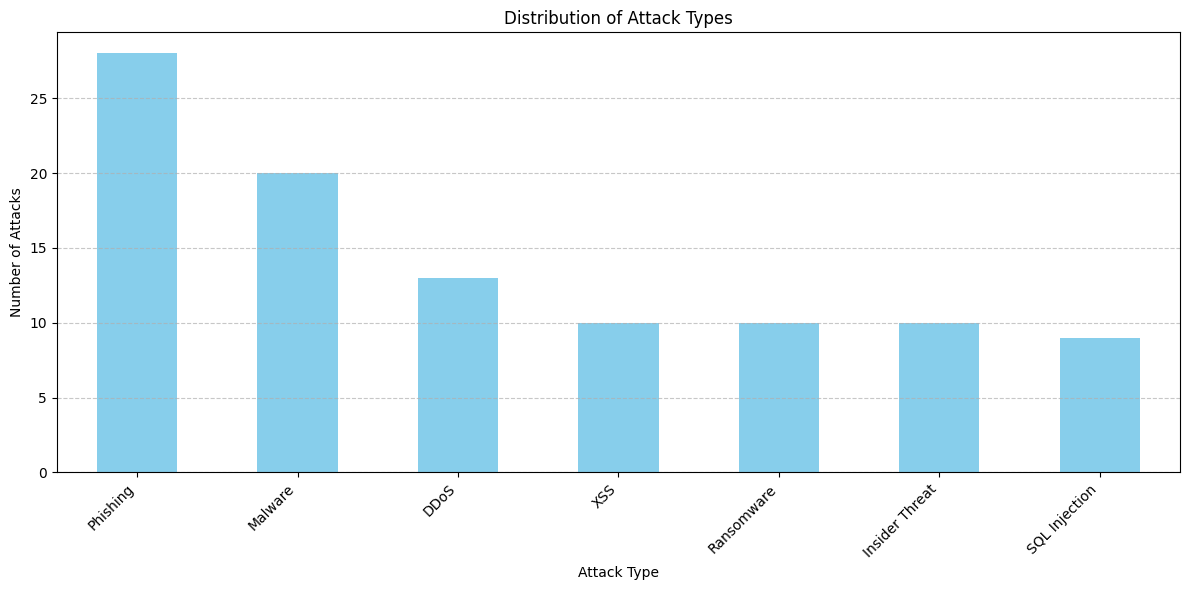

In [5]:
# Plot a bar chart for attack types
plt.figure(figsize=(12, 6))
attack_type_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

#### Pie Chart for Attack Severity

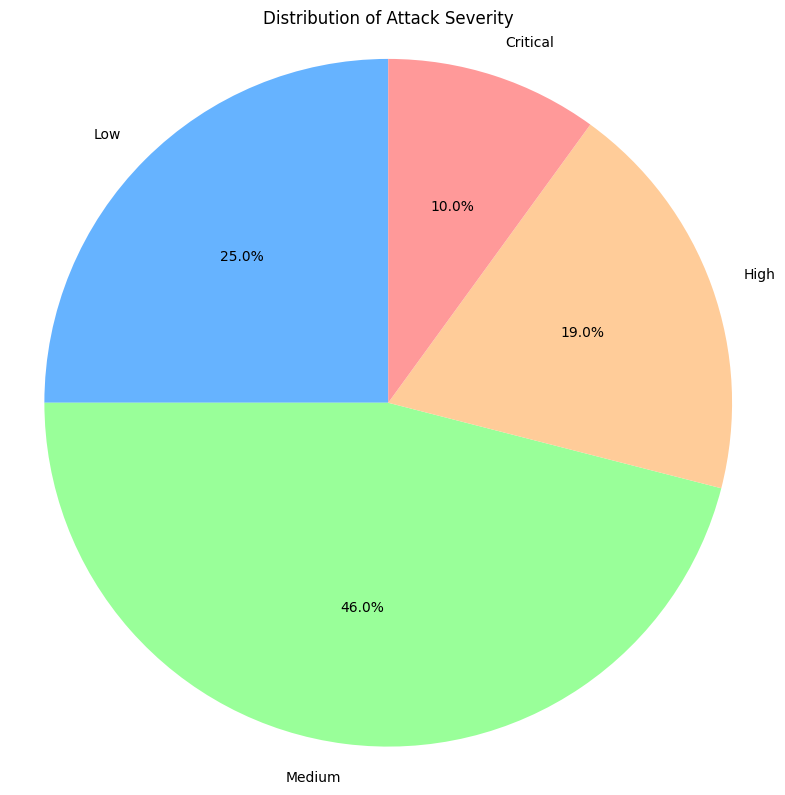

In [6]:
# Plot a pie chart for attack severity
plt.figure(figsize=(8, 8))
# Use autopct to show percentage values on the pie slices
# '%.1f%%' formats the percentage to one decimal place
severity_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99','#ffcc99','#ff9999'])
plt.title('Distribution of Attack Severity')
plt.ylabel('') # Hide the default 'Severity' label on the y-axis for pie charts
plt.axis('equal') # Ensures the pie chart is circular
plt.tight_layout()
plt.show()

### 5. Print Top 5 Most Common Attack Types

In [7]:
# Print the top 5 most common attack types
top_5_attack_types = attack_type_counts.head(5)
print("\nTop 5 Most Common Attack Types:")
display(top_5_attack_types)


Top 5 Most Common Attack Types:


,count
Attack_Type,
Phishing,28
Malware,20
DDoS,13
XSS,10
Ransomware,10
